
<table width="100%">
  <td style="font-size:30px;text-align:left;background-color:rgba(150, 123, 182, 0.7);font-style:italic;">
    Deutsch-Jozsa algorithm.<br>
    <span style="font-size:25px;font-style:normal;">
    Borja Álvarez Reguera & Alicia de la Varga Cabero.
    </span>
  </td>
</table>

<p style="font-size:22px; font-weight:bold;">Deutsch–Jozsa algorithm.</p>

The **Deutsch–Jozsa algorithm** is one of the earliest quantum algorithms showing how quantum computation can outperform classical approaches.  
It determines whether a given Boolean function $f: \{0,1\}^n \rightarrow \{0,1\}$ is **constant** (same output for all inputs) or **balanced** (returns 0 for half the inputs and 1 for the other half).

Classically, in the worst case, one needs to evaluate $f(x)$ for $2^{n-1} + 1$ different inputs to guarantee the correct answer.  
Quantum mechanically, the Deutsch–Jozsa algorithm can determine this **with a single oracle query**, thanks to the use of **superposition** and **quantum interference**.

In this task, we will:
- Implement a **general oracle** $U_f$ that encodes an arbitrary Boolean function $f(x)$ as a phase flip: $U_f |x\rangle = (-1)^{f(x)} |x\rangle$
- Build a **Deutsch–Jozsa wrapper function** that runs the complete algorithm for any given $f$ and number of q-bits $n$.
- Test the algorithm with different oracles — both **constant** and **balanced** — and analyze the resulting quantum measurement outcomes.

In [1]:
# Import packages & classes
    # Classical Python Packages
import numpy as np
import matplotlib.pyplot as plt
    # Qiskit tools :)
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

<p style="font-size:18px; font-weight:bold;">Oracle construction.</p>

In this section, we build the **oracle** $U_f$ corresponding to a Boolean function $f : \{0,1\}^n \rightarrow \{0,1\}$. It is easier to treat $f$ as a funcion defined over the natural numbers from 0 to $2^n -1$ corresponding in the decimal base to each of the bitstrings in $\{0,1\}^n$, so that is what we will do.

The oracle acts on computational basis states as  

$$
U_f |x\rangle = (-1)^{f(x)} |x\rangle
$$

which means that the **phase of the state** $|x\rangle$ is flipped when $f(x) = 1$.  
This phase encoding allows the Deutsch–Jozsa algorithm to distinguish between **balanced** and **constant** functions using a single query to the oracle.

The circuit is constructed dynamically by:
1. Iterating over all possible bitstrings $|x\rangle$.
2. Applying a set of $X$ gates if f(x)=1 to map the current basis state to $|11\dots1\rangle$.
3. Applying a multi-controlled $Z$ gate to flip the phase of this state.
4. Undoing the $X$ gates to return to the computational basis.

This process creates a general oracle that can represent *any* function $f(x)$ by flipping the appropriate basis states.


In [2]:
def oracle(qc, f, n):
    """
    Build the Deutsch–Jozsa oracle for a given Boolean function f: {0,1}^n -> {0,1}.
    The oracle applies a phase flip (multiplies by -1) to the computational basis states |x⟩
    for which f(x) = 1.

    Parameters:
        qc (QuantumCircuit): The quantum circuit where the oracle will be applied.
        f (function): A classical Boolean function that takes an integer x (0 <= x <= 2^n-1)
                      and returns 0 or 1.
        n (int): Number of input q-bits.
    """
    for x in range(2**n):
        if f(x) == 1:
            # The goal is to apply a phase shift (-1) to all basis states |x⟩ satisfying f(x) = 1.

            # Convert the integer x into its binary representation with n bits.
            bits = format(x, f'0{n}b')

            # For each q-bit where the binary string has a '0',
            # apply an X gate to map |x⟩ to |11...1⟩.
            # This prepares the state for the multi-controlled X (mcx) gate,
            # which activates only when all control q-bits are |1⟩.
            for i, bit in enumerate(bits):
                if bit == '0': qc.x(i)

            # Apply the multi-controlled X gate on the ancilla q-bit.
            # This introduces a phase of -1 on the corresponding |x⟩ state.
            qc.mcx(list(range(n)), n)

            # Revert the earlier X gates to return to the original computational basis.
            # The information of f(x) remains encoded in the phases.
            for i, bit in enumerate(bits):
                if bit == '0': qc.x(i)

<p style="font-size:18px; font-weight:bold;">Algorithm outline & implementation.</p>

1. **Initialization**  
   We start with $n$ input q-bits and one ancilla q-bit in the state $|0\rangle^{\otimes n}$. The ancilla is then transformed into the state $|-\rangle$ to enable phase kickback from the oracle.

2. **Superposition**  
   Apply Hadamard gates to all q-bits, creating a uniform superposition of all possible input states:  
   $$
   \frac{1}{\sqrt{2^n}} \sum_{x=0}^{2^n-1} |x\rangle \otimes |-\rangle
   $$

3. **Oracle application**  
   The oracle $U_f$ acts as $U_f|x\rangle|y\rangle = |x\rangle|y \oplus f(x)\rangle$ where $\oplus$ denotes addition modulo 2. Due to the ancilla being in $|-\rangle$, this effectively encodes $f(x)$ as a **phase shift**:  
   $$
   U_f|x\rangle|-\rangle = (-1)^{f(x)}|x\rangle|-\rangle
   $$

5. **Interference and measurement**  
   After applying Hadamard gates again to the input q-bits, the interference pattern reveals the nature of $f$.  
   - If $f$ is **constant**, all amplitude remains in the $|0\rangle^{\otimes n}$ state.  
   - If $f$ is **balanced**, destructive interference removes this component, giving a different measurement outcome.

Thus, by measuring the input q-bits:
- The result $|0\rangle^{\otimes n}$ indicates a **constant** function.  
- Any other outcome indicates a **balanced** function.

---

In our implementation, we first verify that the provided function $f$ satisfies the required properties (only outputs 0 or 1, and is either constant or balanced). Then, we build and simulate the corresponding quantum circuit, visualize it, and interpret the resulting measurement histogram.

In [3]:
def deutsch_jozsa_run(f, n):
    """
    Runs the Deutsch–Jozsa algorithm for a given Boolean function f and n input q-bits.

    Parameters:
    f (function): A Boolean function that takes an integer x in [0, 2^n - 1] and returns 0 or 1.
    n (int): Number of input q-bits (excluding the ancilla q-bit).
    """

    # --- Step 1: Check if the function f is constant or balanced ---

    # Evaluate f(x) for all possible inputs
    values = [f(x) for x in range(2**n)]

    # Ensure all outputs are valid (0 or 1)
    if any(v not in [0, 1] for v in values):
        raise ValueError("Function f(x) must only return 0 or 1.")

    # Check whether the function is valid for Deutsch–Jozsa
    count_ones = sum(values)
    if not (count_ones == 0 or count_ones == 2**(n-1) or count_ones == 2**n):
        raise ValueError("Function f(x) must be either constant or balanced.")

    # --- Step 2: Build the quantum circuit ---

    # Create a circuit with n input q-bits and 1 ancilla q-bit, and n classical bits for measurement
    qc = QuantumCircuit(n + 1, n)

    # Initialize the ancilla q-bit in |-> = (|0> - |1>)/√2
    qc.x(n)
    qc.h(n)

    # Apply Hadamard gates to all input q-bits to create superposition
    for i in range(n): qc.h(i)
    qc.barrier()

    # --- Step 3: Apply the oracle Uf ---
    oracle(qc, f, n)
    qc.barrier()

    # --- Step 4: Apply Hadamard gates again to perform interference ---
    for i in range(n): qc.h(i)

    # --- Step 5: Measure all input q-bits ---
    for i in range(n): qc.measure(i, i)

    # --- Step 6: Simulate the circuit (1 shot is enough)---
    counts = AerSimulator().run(qc, shots=1).result().get_counts()

    # --- Step 7: Interpret the result ---
    # If the result is all zeros, the function is constant
    # Otherwise, the function is balanced
    output = list(counts.keys())[0]
    if output == '0' * n: print("The function is constant.")
    else: print("The function is balanced.")

    # Display the circuit
    display(qc.draw('mpl'))
    return qc, counts

<p style="font-size:18px; font-weight:bold;">Testing the algorithm.</p>

Now that the Deutsch–Jozsa algorithm and its oracle have been implemented, it is time to verify that the function checker and the algorithm behave as expected.

We will test several Boolean functions $f:\{0,1\}^n \to \{0,1\}$, including both valid (constant or balanced) and invalid cases to ensure that the input validation works correctly.

The following test cases will be considered:
1. Constant function $f(x) = 0$ for all $x$ ($n=2$).
2. Balanced function $f(x) = x_0 \oplus x_1$ ($n=2$).
3. Constant function $f(x) = 1$ for all $x$ ($n=3$).
4. Invalid function (unbalanced): returns 1 for only one input ($n=3$).
5. Balanced function $f(x) = (x_0 + x_1 + x_2) \bmod 2$ ($n=3$).

We expect:
- The algorithm to classify correctly the constant and balanced functions.
- The invalid case to raise an error before building the quantum circuit.



--- Testing: Constant (f=0), n=2 ---
The function is constant.


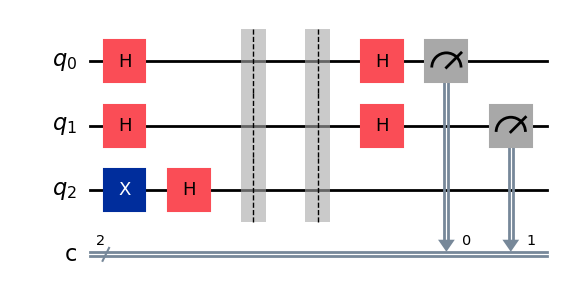


--- Testing: Balanced (XOR), n=2 ---
The function is balanced.


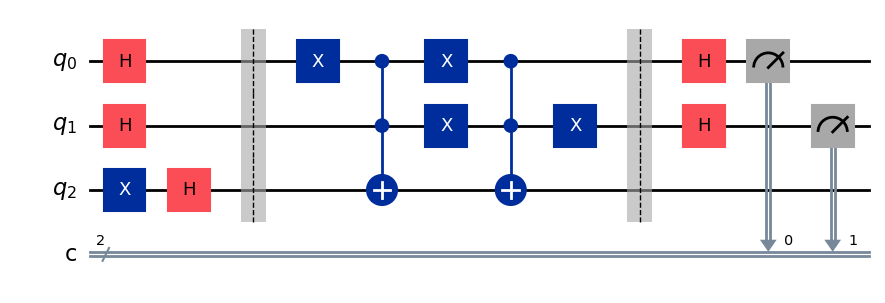


--- Testing: Constant (f=1), n=3 ---
The function is constant.


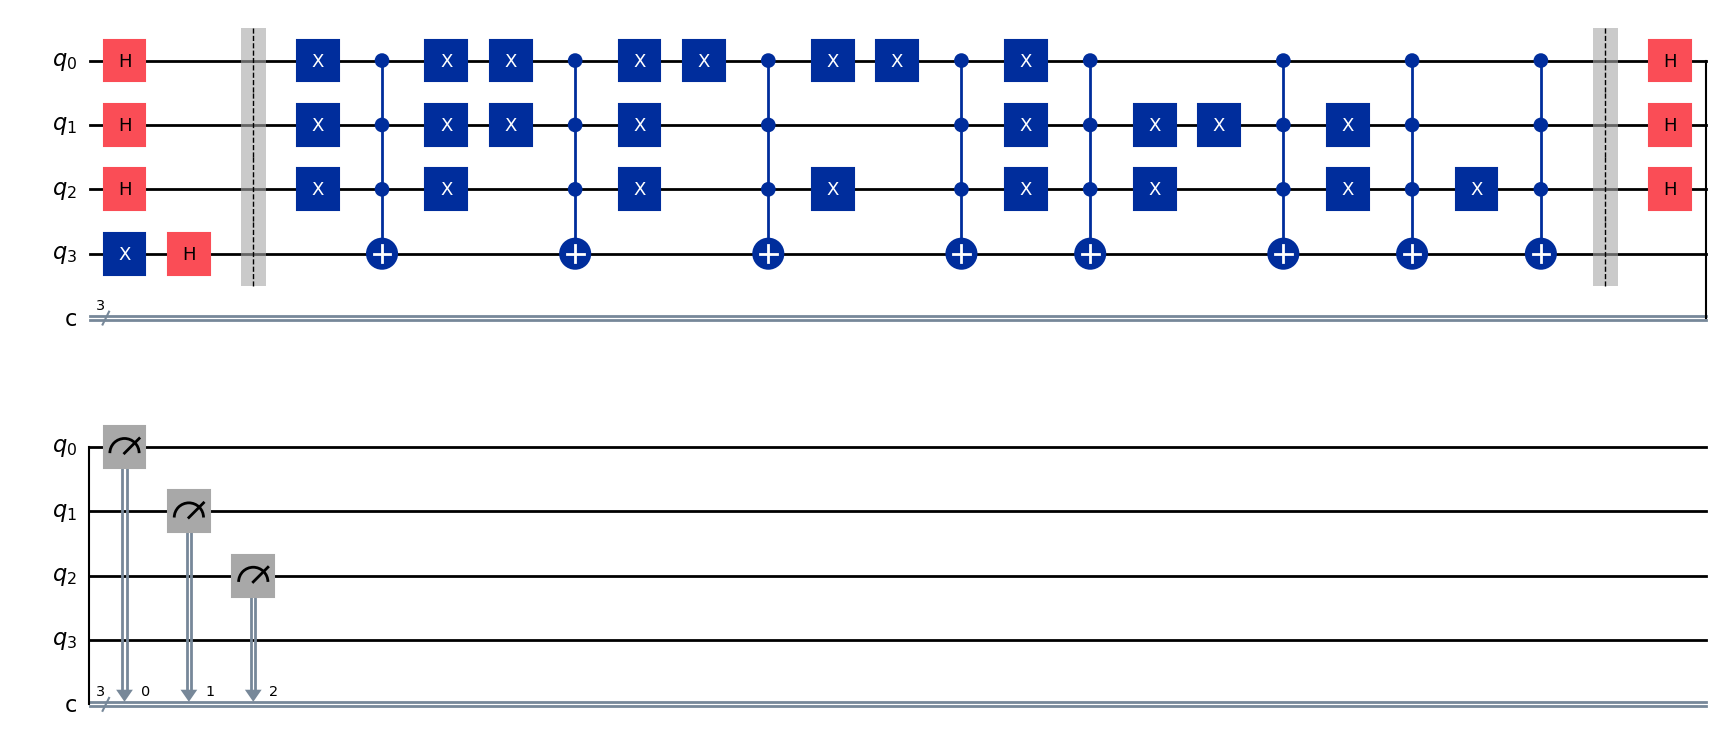


--- Testing: Invalid (Unbalanced), n=3 ---
Error detected: Function f(x) must be either constant or balanced.

--- Testing: Balanced (sum mod 2), n=3 ---
The function is balanced.


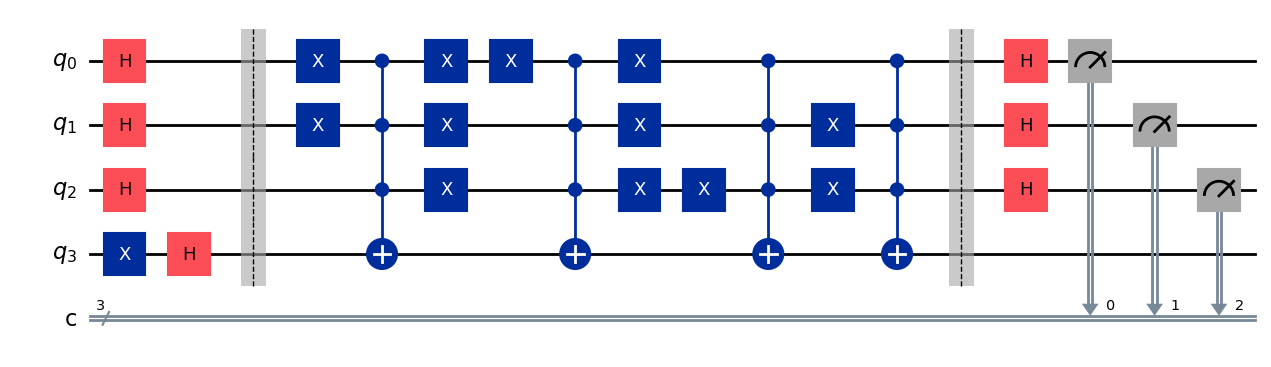

In [4]:
# Define test functions of different kinds

# 1. Constant (always 0)
def f_const_0(x):
    return 0

# 2. Balanced: f(x) = x0 XOR x1
def f_balanced_xor(x):
    bits = format(x, '02b')
    return int(bits[0]) ^ int(bits[1])

# 3. Constant (always 1)
def f_const_1(x):
    return 1

# 4. Invalid: unbalanced (returns 1 for only one input)
def f_invalid_unbalanced(x):
    return 1 if x == 0 else 0

# 5. Balanced: f(x) = (x0 + x1 + x2) mod 2
def f_balanced_sum(x):
    bits = format(x, '03b')
    return (int(bits[0]) + int(bits[1]) + int(bits[2])) % 2


# --- Run tests ---
test_cases = [
    (f_const_0, 2, "Constant (f=0)"),
    (f_balanced_xor, 2, "Balanced (XOR)"),
    (f_const_1, 3, "Constant (f=1)"),
    (f_invalid_unbalanced, 3, "Invalid (Unbalanced)"),
    (f_balanced_sum, 3, "Balanced (sum mod 2)"),
]

for f, n, desc in test_cases:
    print(f"\n--- Testing: {desc}, n={n} ---")
    try:
        qc, counts = deutsch_jozsa_run(f, n)
    except ValueError as e:
        print("Error detected:", e)